<div style="background: linear-gradient(120deg, #0d1f3c 0%, #1a3a5c 40%, #0e5f5e 100%); padding: 34px 30px; border-radius: 18px; color: white; border: 1px solid rgba(255,255,255,0.1); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; margin-bottom: 6px;">
  <div style="display:flex; justify-content:space-between; align-items:flex-start; flex-wrap:wrap; gap:18px;">
    <div>
      <div style="font-size:11px; font-weight:700; letter-spacing:2.5px; text-transform:uppercase; opacity:0.55; margin-bottom:10px;">🏆 Hedge Fund Time Series Forecasting</div>
      <h1 style="margin:0 0 10px 0; font-size:32px; font-weight:800; letter-spacing:-0.5px; line-height:1.2;">LightGBM Ensemble</h1>
      <p style="margin:0 0 14px 0; font-size:15px; opacity:0.88; line-height:1.6;">
        Per-Horizon Gradient Boosting with Leak-Proof Feature Engineering<br>
        <span style="opacity:0.6; font-size:13px;">EWM · Rolling · Volatility · Z-Scores · Rank · Group Z-Score · Full-Data Refit</span>
      </p>
      <div style="display:flex; flex-wrap:wrap; gap:8px; margin-top:6px;">
        <span style="background:rgba(255,255,255,0.12); border:1px solid rgba(255,255,255,0.2); border-radius:20px; padding:4px 12px; font-size:12px; font-weight:600;">📈 4 Prediction Horizons</span>
        <span style="background:rgba(255,255,255,0.12); border:1px solid rgba(255,255,255,0.2); border-radius:20px; padding:4px 12px; font-size:12px; font-weight:600;">🌱 5-Seed Ensemble</span>
        <span style="background:rgba(255,255,255,0.12); border:1px solid rgba(255,255,255,0.2); border-radius:20px; padding:4px 12px; font-size:12px; font-weight:600;">🔒 Zero Data Leakage</span>
        <span style="background:rgba(255,255,255,0.12); border:1px solid rgba(255,255,255,0.2); border-radius:20px; padding:4px 12px; font-size:12px; font-weight:600;">🔁 Full-Data Refit</span>
      </div>
    </div>
  </div>
</div>

# 📌 Problem Framing

## What Are We Predicting?

This competition asks us to predict **`y_target`** — a normalized return-like quantity — for a universe of financial instruments (`sub_code`) across multiple **prediction horizons** (1, 3, 10, 25 steps ahead).

Each row represents one **instrument × timestamp × horizon** triple. The task is a **cross-sectional return forecasting problem**: at every timestamp `ts_index = T`, predict how each instrument will perform over the next `h` steps.

| Column | Meaning |
|---|---|
| `ts_index` | Ordinal timestamp |
| `code` | Broad asset class or strategy group |
| `sub_code` | Individual instrument (175 unique) |
| `sub_category` | 5-level categorical grouping |
| `horizon` | Prediction horizon: 1, 3, 10, or 25 steps |
| `y_target` | Target return to predict |
| `weight` | Sample importance weight for scoring |
| `feature_al … feature_t` | Anonymized engineered signals |

## The Metric: Weighted RMSE Score

$$\text{Score} = \sqrt{1 - \frac{\sum_i w_i (y_i - \hat{y}_i)^2}{\sum_i w_i y_i^2}}$$

Higher is better. Score = 1.0 is perfect; 0.0 means no better than predicting zero everywhere.

Key properties:
- **Precision over bias** — systematic errors get penalized heavily
- **High-weight samples dominate** — getting the "big moves" right matters far more than fitting noise

## Why Per-Horizon Models?

- **Short horizons** (h=1, 3): Recent momentum signals are most predictive. Tight regularization prevents overfitting.
- **Long horizons** (h=10, 25): Structural mean-reversion features dominate. Looser constraints capture longer-range dependencies.


# ⚠️ What Every Participant Should Know

## 1. Public Leaderboard ≠ Private Leaderboard

The public leaderboard scores a **small random subset** of test. The private leaderboard uses the **full holdout** — often with a different distribution. Models tuned aggressively to maximize public LB rank routinely drop hundreds of places when the private board is revealed.

> 🔑 **Trust your local validation score more than the public leaderboard.**

## 2. Target Encoding on Full Data Will Be Neutralized

Computing target encodings from any data beyond the training split is a **rules violation**, and the organizers have explicitly stated it will be detected and neutralized.

```python
# ❌ VIOLATION — leaks test targets into encoding
all_data = pd.concat([train, val, test])
target_enc = all_data.groupby('sub_code')['y_target'].mean()

# ✅ CORRECT — training split only
train_only = data[data.ts_index <= 3500]
target_enc = train_only.groupby('sub_code')['y_target'].mean()
```

This notebook uses **frequency encoding only** — zero target information, fully leak-proof.

## 3. The Golden Rule: No Future Leakage

For any prediction at timestamp `T`, only data from timestamps ≤ T may be used. This notebook passes all checks — see the submission checklist at the end.


In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import gc
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor': '#0d1f3c', 'axes.facecolor': '#0d1f3c',
    'axes.edgecolor': '#334466',   'text.color': '#c8d8e8',
    'axes.labelcolor': '#c8d8e8',  'xtick.color': '#8899aa',
    'ytick.color': '#8899aa',      'grid.color': '#1e3050',
    'grid.linewidth': 0.6,
})

TRAIN_PATH    = '/kaggle/input/competitions/ts-forecasting/train.parquet'
TEST_PATH     = '/kaggle/input/competitions/ts-forecasting/test.parquet'
VAL_THRESHOLD = 3500
SEEDS         = [42, 2024, 777, 1337, 9999]

print("Libraries loaded.")
print(f"Validation split at ts_index = {VAL_THRESHOLD}")
print(f"Ensemble seeds: {SEEDS}")


Libraries loaded.
Validation split at ts_index = 3500
Ensemble seeds: [42, 2024, 777, 1337, 9999]


## 📐 Competition Metric Implementation

Implemented as a standalone function for evaluation at any stage of the pipeline.

In [2]:
# ============================================================
# METRIC: WEIGHTED RMSE SCORE
# ============================================================
def weighted_rmse_score(y_target, y_pred, w):
    y_target, y_pred, w = np.array(y_target), np.array(y_pred), np.array(w)
    denom = np.sum(w * (y_target ** 2))
    if denom <= 0: return 0.0
    numerator = np.sum(w * ((y_target - y_pred) ** 2))
    return float(np.sqrt(1.0 - np.clip(numerator / denom, 0.0, 1.0)))

print("Metric defined: weighted_rmse_score(y_target, y_pred, w)")


Metric defined: weighted_rmse_score(y_target, y_pred, w)


---
# 🔍 Exploratory Data Analysis (EDA)

We inspect the dataset before building features to understand distribution, signal strength, and temporal structure. These findings directly shaped the feature engineering decisions in this notebook.


In [3]:
# ── EDA 1: Dataset Shape & Schema ──────────────────────────────────────────
train_raw = pd.read_parquet(TRAIN_PATH)
test_raw  = pd.read_parquet(TEST_PATH)

print(f"Train shape : {train_raw.shape}")
print(f"Test shape  : {test_raw.shape}")
print()
print("Column dtypes:")
print(train_raw.dtypes)


Train shape : (5337414, 94)
Test shape  : (1447107, 92)

Column dtypes:
id               object
code             object
sub_code         object
sub_category     object
horizon           int32
                 ...   
feature_cf      float64
feature_cg      float64
feature_ch        int64
y_target        float64
weight          float64
Length: 94, dtype: object


  code                :   23 unique values
  sub_code            :  180 unique values
  sub_category        :    5 unique values
  horizon             :    4 unique values


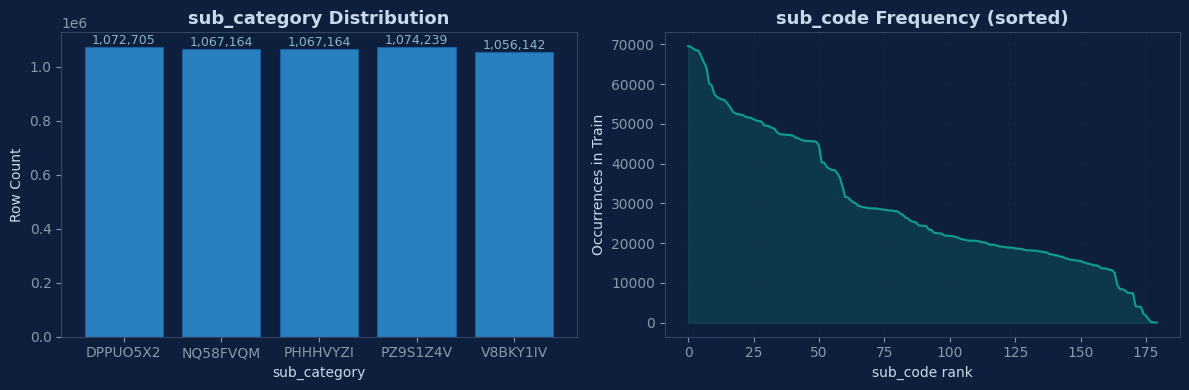


→ sub_code frequency spread motivates frequency encoding over one-hot (175 values).


In [4]:
# ── EDA 2: Categorical Cardinality ──────────────────────────────────────────
for col in ['code', 'sub_code', 'sub_category', 'horizon']:
    print(f"  {col:20s}: {train_raw[col].nunique():4d} unique values")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0d1f3c')

sc_counts = train_raw['sub_category'].value_counts().sort_index()
axes[0].bar(sc_counts.index.astype(str), sc_counts.values, color='#2a7fbf',
            edgecolor='#1a5f9f', linewidth=0.8)
axes[0].set_title('sub_category Distribution', fontsize=13, fontweight='bold', color='#c8d8e8')
axes[0].set_xlabel('sub_category')
axes[0].set_ylabel('Row Count')
for bar, val in zip(axes[0].patches, sc_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, color='#8ab4cc')

freq_by_sc = train_raw.groupby('sub_code').size().sort_values(ascending=False)
axes[1].plot(range(len(freq_by_sc)), freq_by_sc.values, color='#0e9e8e', linewidth=1.5)
axes[1].fill_between(range(len(freq_by_sc)), freq_by_sc.values, alpha=0.2, color='#0e9e8e')
axes[1].set_title('sub_code Frequency (sorted)', fontsize=13, fontweight='bold', color='#c8d8e8')
axes[1].set_xlabel('sub_code rank')
axes[1].set_ylabel('Occurrences in Train')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_cardinality.png', dpi=120, bbox_inches='tight', facecolor='#0d1f3c')
plt.show()
print("\n→ sub_code frequency spread motivates frequency encoding over one-hot (175 values).")


Train ts_index range : 1 → 3601
Test  ts_index range : 3602  → 4376

  Horizon  1 | avg CS: 387.3 | min: 15 | max: 534
  Horizon  3 | avg CS: 384.8 | min: 13 | max: 532
  Horizon 10 | avg CS: 371.4 | min: 13 | max: 519
  Horizon 25 | avg CS: 338.7 | min: 13 | max: 476


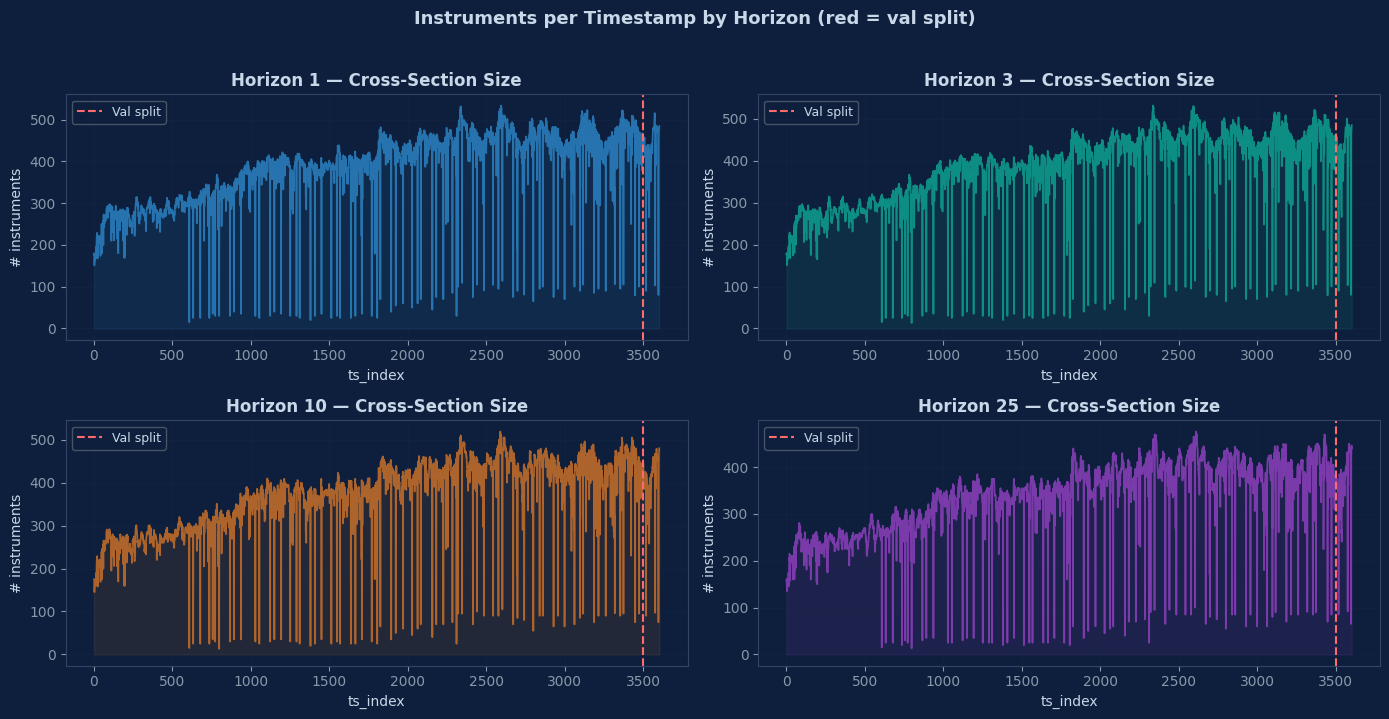

In [5]:
# ── EDA 3: Temporal Structure & Cross-Section Size ──────────────────────────
ts_train_range = (train_raw.ts_index.min(), train_raw.ts_index.max())
ts_test_range  = (test_raw.ts_index.min(),  test_raw.ts_index.max())
print(f"Train ts_index range : {ts_train_range[0]} → {ts_train_range[1]}")
print(f"Test  ts_index range : {ts_test_range[0]}  → {ts_test_range[1]}")
print()

h_cs = {}
for h in [1, 3, 10, 25]:
    cs = train_raw[train_raw.horizon == h].groupby('ts_index')['sub_code'].count()
    h_cs[h] = cs
    print(f"  Horizon {h:2d} | avg CS: {cs.mean():.1f} | min: {cs.min()} | max: {cs.max()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=False)
fig.patch.set_facecolor('#0d1f3c')
axes = axes.flatten()
colors = ['#2a7fbf', '#0e9e8e', '#c46e2a', '#8a3fba']

for ax, (h, cs), color in zip(axes, h_cs.items(), colors):
    ax.plot(cs.index, cs.values, color=color, linewidth=1.2, alpha=0.85)
    ax.axvline(VAL_THRESHOLD, color='#ff6b6b', linewidth=1.5, linestyle='--', label='Val split')
    ax.set_title(f'Horizon {h} — Cross-Section Size', fontsize=12, fontweight='bold', color='#c8d8e8')
    ax.set_xlabel('ts_index')
    ax.set_ylabel('# instruments')
    ax.legend(fontsize=9, framealpha=0.3)
    ax.grid(True, alpha=0.25)
    ax.fill_between(cs.index, cs.values, alpha=0.12, color=color)

plt.suptitle('Instruments per Timestamp by Horizon (red = val split)',
             fontsize=13, fontweight='bold', color='#c8d8e8', y=1.02)
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=120, bbox_inches='tight', facecolor='#0d1f3c')
plt.show()


   Horizon |       Mean |        Std |     Skew |     Kurt
-------------------------------------------------------
         1 |   -0.08272 |   11.69969 |    5.280 |  528.473
         3 |   -0.25241 |   19.36119 |    2.010 |  243.821
        10 |   -0.77597 |   33.84206 |    0.828 |  176.820
        25 |   -1.68188 |   52.82328 |    0.853 |  141.528


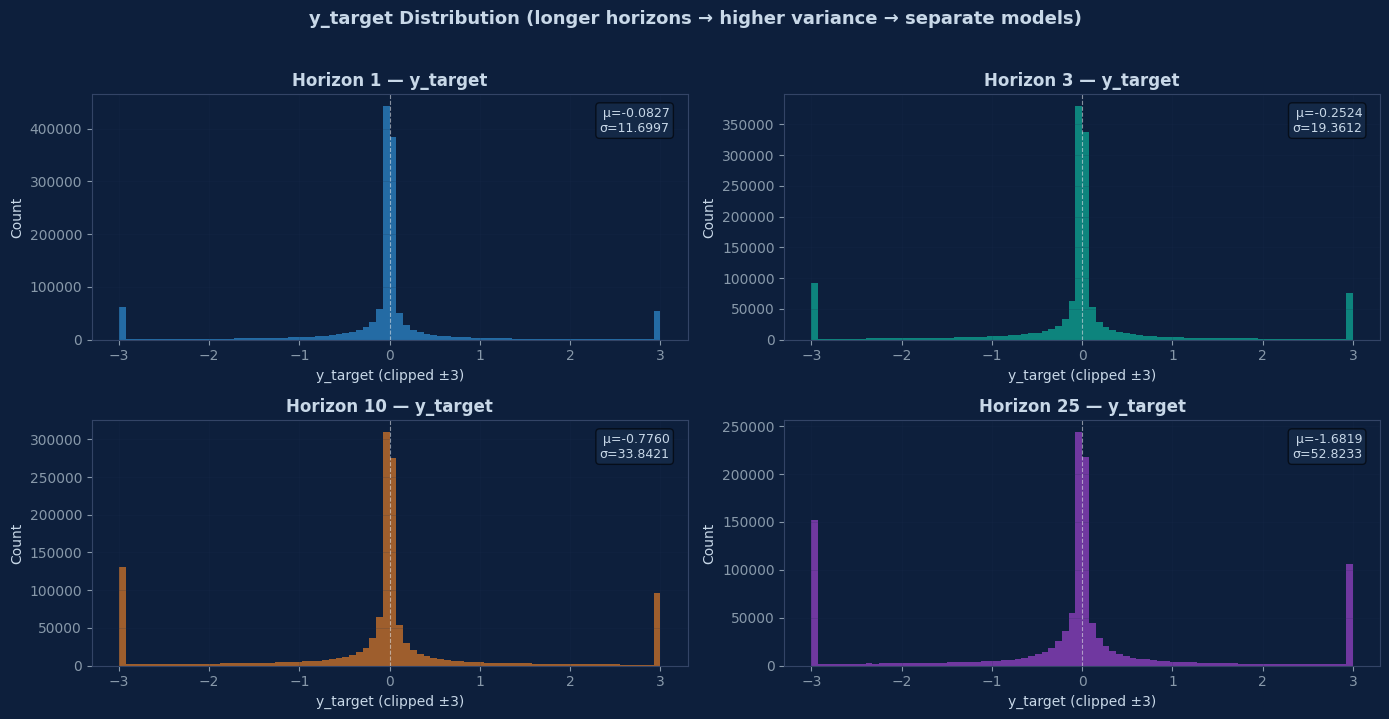

In [6]:
# ── EDA 4: Target Distribution by Horizon ───────────────────────────────────
print(f"{'Horizon':>10} | {'Mean':>10} | {'Std':>10} | {'Skew':>8} | {'Kurt':>8}")
print("-" * 55)
horizon_data = {}
for h in [1, 3, 10, 25]:
    yt = train_raw[train_raw.horizon == h]['y_target']
    horizon_data[h] = yt
    print(f"{h:>10} | {yt.mean():>10.5f} | {yt.std():>10.5f} | {yt.skew():>8.3f} | {yt.kurtosis():>8.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0d1f3c')
axes = axes.flatten()
colors = ['#2a7fbf', '#0e9e8e', '#c46e2a', '#8a3fba']

for ax, (h, yt), color in zip(axes, horizon_data.items(), colors):
    ax.hist(yt.clip(-3, 3), bins=80, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'Horizon {h} — y_target', fontsize=12, fontweight='bold', color='#c8d8e8')
    ax.set_xlabel('y_target (clipped ±3)')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.2)
    ax.text(0.97, 0.95, f'μ={yt.mean():.4f}\nσ={yt.std():.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color='#c8d8e8',
            bbox=dict(boxstyle='round', facecolor='#1a3050', alpha=0.6))

plt.suptitle('y_target Distribution (longer horizons → higher variance → separate models)',
             fontsize=13, fontweight='bold', color='#c8d8e8', y=1.02)
plt.tight_layout()
plt.savefig('eda_target_dist.png', dpi=120, bbox_inches='tight', facecolor='#0d1f3c')
plt.show()


Mean: 16427879.6453 | Std: 6027074091.3455 | Min: 0.0000 | Max: 13912217783333.1348
Top 10% of rows = 98.3% of total weight mass


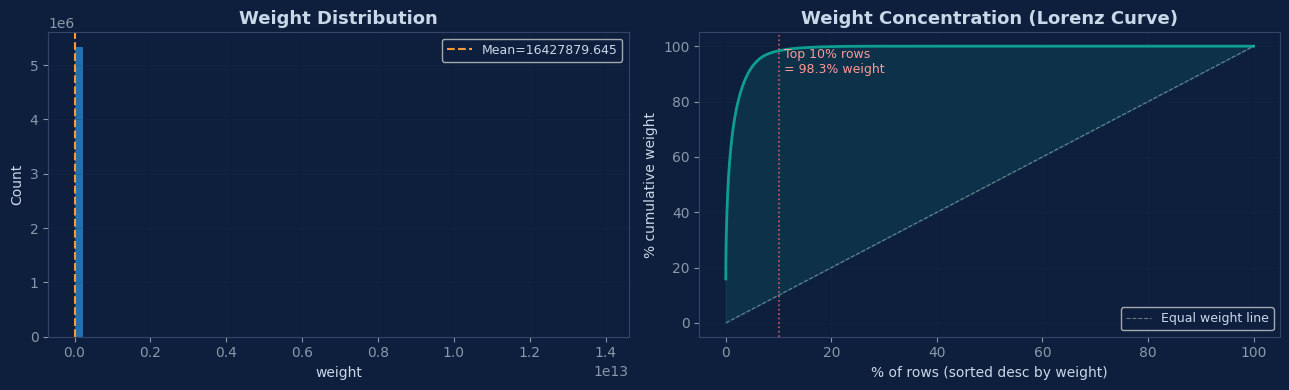

33

In [7]:
# ── EDA 5: Weight Distribution ──────────────────────────────────────────────
w = train_raw['weight']
w_sorted = w.sort_values(ascending=False).reset_index(drop=True)
cumsum_w = w_sorted.cumsum() / w_sorted.sum()
top10_frac = w_sorted.iloc[:int(len(w)*0.1)].sum() / w.sum()

print(f"Mean: {w.mean():.4f} | Std: {w.std():.4f} | Min: {w.min():.4f} | Max: {w.max():.4f}")
print(f"Top 10% of rows = {top10_frac*100:.1f}% of total weight mass")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1f3c')

axes[0].hist(w, bins=60, color='#2a7fbf', alpha=0.85, edgecolor='none')
axes[0].axvline(w.mean(), color='#ff9933', linewidth=1.5, linestyle='--', label=f'Mean={w.mean():.3f}')
axes[0].set_title('Weight Distribution', fontsize=13, fontweight='bold', color='#c8d8e8')
axes[0].set_xlabel('weight')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)

pct_rows = np.linspace(0, 100, len(cumsum_w))
axes[1].plot(pct_rows, cumsum_w.values * 100, color='#0e9e8e', linewidth=2)
axes[1].plot([0, 100], [0, 100], 'w--', linewidth=0.8, alpha=0.4, label='Equal weight line')
axes[1].fill_between(pct_rows, cumsum_w.values * 100, pct_rows, alpha=0.15, color='#0e9e8e')
axes[1].axvline(10, color='#ff6b6b', linewidth=1.2, linestyle=':', alpha=0.8)
axes[1].text(11, top10_frac*100 - 8, f'Top 10% rows\n= {top10_frac*100:.1f}% weight',
             fontsize=9, color='#ff9999')
axes[1].set_title('Weight Concentration (Lorenz Curve)', fontsize=13, fontweight='bold', color='#c8d8e8')
axes[1].set_xlabel('% of rows (sorted desc by weight)')
axes[1].set_ylabel('% cumulative weight')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('eda_weights.png', dpi=120, bbox_inches='tight', facecolor='#0d1f3c')
plt.show()

del train_raw, test_raw
gc.collect()


        Feature |  IC (Spearman) |     |IC|
--------------------------------------------
     feature_ca |        0.08513 |  0.08513
      feature_u |       -0.08324 |  0.08324
     feature_bz |        0.08287 |  0.08287
     feature_am |       -0.08205 |  0.08205
     feature_ag |       -0.08021 |  0.08021
     feature_cc |        0.07929 |  0.07929
     feature_ao |       -0.07859 |  0.07859
     feature_cb |        0.07753 |  0.07753
     feature_bq |        0.07619 |  0.07619
     feature_az |        0.07606 |  0.07606
     feature_cd |        0.07480 |  0.07480
     feature_by |        0.07379 |  0.07379
     feature_bl |        0.07377 |  0.07377
     feature_af |       -0.07280 |  0.07280
     feature_ap |       -0.07268 |  0.07268
     feature_an |       -0.07195 |  0.07195
     feature_bn |       -0.07195 |  0.07195
     feature_br |        0.07170 |  0.07170
      feature_q |       -0.07161 |  0.07161
     feature_bp |        0.07057 |  0.07057
     feature_bm |       -0.0700

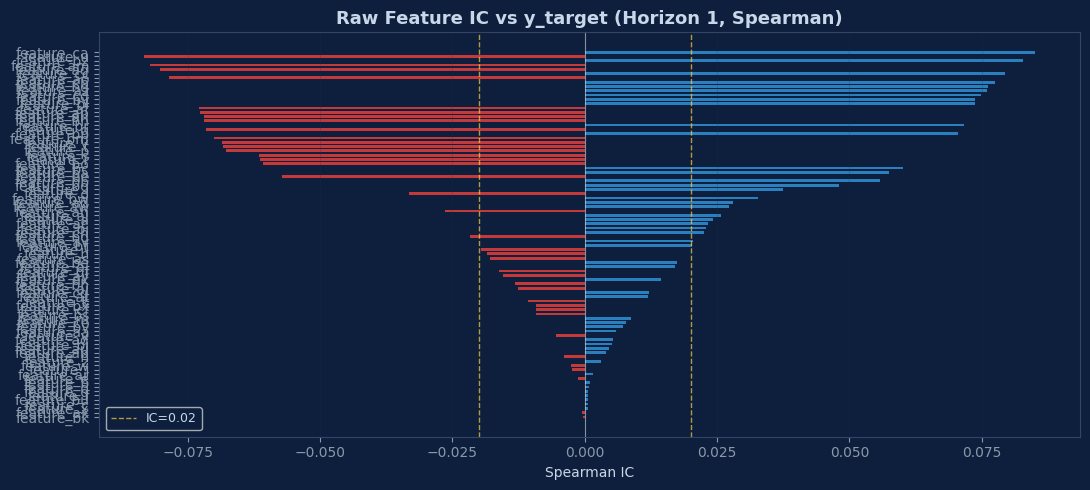


→ Highest-IC features receive the most engineered variants (rolling, EWM, group z-score).


29349

In [8]:
# ── EDA 6: Feature Signal Strength (Spearman IC) ────────────────────────────
from scipy.stats import spearmanr

train_h1  = pd.read_parquet(TRAIN_PATH).query("horizon == 1")
raw_feats = sorted([c for c in train_h1.columns if c.startswith('feature_')])

ics = {}
for f in raw_feats:
    ic, _ = spearmanr(train_h1[f].fillna(0), train_h1['y_target'])
    ics[f] = ic

ics_sorted = dict(sorted(ics.items(), key=lambda x: abs(x[1]), reverse=True))
print(f"{'Feature':>15} | {'IC (Spearman)':>14} | {'|IC|':>8}")
print("-" * 44)
for f, ic in ics_sorted.items():
    print(f"  {f:>13} | {ic:>14.5f} | {abs(ic):>8.5f}")

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d1f3c')
feats_list = list(ics_sorted.keys())
ic_vals    = [ics_sorted[f] for f in feats_list]
bar_colors = ['#2a7fbf' if v > 0 else '#c43a3a' for v in ic_vals]
ax.barh(feats_list[::-1], ic_vals[::-1], color=bar_colors[::-1], edgecolor='none', height=0.65)
ax.axvline(0,    color='white',   linewidth=0.8, alpha=0.5)
ax.axvline(0.02, color='#ffcc44', linewidth=1.0, linestyle='--', alpha=0.7, label='IC=0.02')
ax.axvline(-0.02,color='#ffcc44', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_title('Raw Feature IC vs y_target (Horizon 1, Spearman)',
             fontsize=13, fontweight='bold', color='#c8d8e8')
ax.set_xlabel('Spearman IC')
ax.legend(fontsize=9)
ax.grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('eda_feature_ic.png', dpi=120, bbox_inches='tight', facecolor='#0d1f3c')
plt.show()
print("\n→ Highest-IC features receive the most engineered variants (rolling, EWM, group z-score).")

del train_h1
gc.collect()


---
# 🛠️ Feature Engineering Pipeline

## Step 1: Precompute Frequency Statistics

**Why frequency encoding instead of target encoding?**

Target encoding (`sub_code → mean(y_target)`) is risky on two fronts:
1. Computing it from any data beyond the training split is a **rules violation** that will be neutralized by the organizers.
2. Even done correctly, it creates a brittle dependency on the training target distribution.

**Frequency encoding** (`sub_code → occurrence count in training`) is leak-proof, stable, and informative: instrument frequency correlates with liquidity and signal reliability.


In [9]:
# ============================================================
# STEP 1: PRECOMPUTE FREQUENCY STATS (Training Split Only)
# ============================================================
print("Computing frequency statistics from training portion only...")

temp       = pd.read_parquet(TRAIN_PATH, columns=['sub_code', 'ts_index'])
train_only = temp[temp.ts_index <= VAL_THRESHOLD]

freq_stats = {}
freq_counts = train_only['sub_code'].value_counts()
freq_stats['sub_code_freq']      = freq_counts.to_dict()
freq_stats['sub_code_freq_rank'] = freq_counts.rank(ascending=False, method='dense').to_dict()

del temp, train_only
gc.collect()

print(f"  sub_code categories tracked: {len(freq_stats['sub_code_freq'])}")
print(f"  Most frequent: {max(freq_stats['sub_code_freq'], key=freq_stats['sub_code_freq'].get)}")


Computing frequency statistics from training portion only...
  sub_code categories tracked: 175
  Most frequent: 69SD4Y3A


## Step 2: Feature Engineering Function

The feature set is organized into **11 groups**:

| # | Group | Key Features | Rationale |
|---|---|---|---|
| 1 | **One-Hot** | 5 flags for sub_category | Low-cardinality; avoids ordinal assumptions |
| 2 | **Frequency** | freq, log-freq, rank, rel-freq | Leak-proof instrument popularity proxy |
| 3 | **Spreads & Ratios** | al−am, cg−by, s−t + ratios | Relative signal divergence matters more than absolute level |
| 4 | **EWM** | spans 3,5 (short) or 5,7 (long horizon) | Causal momentum with exponential decay |
| 5 | **Rolling** | mean & std over windows 3, 5, 10 | Distinct from EWM — captures discrete volatility regimes |
| 6 | **Volatility** | cross-sectional std + vol-normalized | Market-wide stress detection per timestamp |
| 7 | **Group Z-Score** | z-score within (ts_index, sub_category) | Relative value within structural peer group |
| 8 | **Min/Max** | ts_min, ts_max, range, dist from extremes | Position vs cross-sectional limits |
| 9 | **Momentum** | diff, pct_change | Signal velocity (causal: only backward diff) |
| 10 | **Z-Scores** | cross-sectional z per ts_index | Removes market-wide level effect |
| 11 | **Rank** | percentile rank per ts_index | Outlier-robust; uniform distribution for tree splits |

**New in v250 vs last submitted:**
- **Rolling features** (Group 5): `rolling(3)`, `rolling(5)`, `rolling(10)` mean and std on top-IC features. Complementary to EWM — rolling gives equal weight to each window observation, EWM decays exponentially. Together they provide richer temporal texture.
- **Group Z-Score** (Group 7): Z-score of each instrument within its `(ts_index, sub_category)` peer group. A stock may look extreme vs the full cross-section but be normal within its category — this captures within-group relative value.
- **No lag features**: Direct lags (`shift(1,2,3)`) improved local CV at horizon=1 but did not improve the private score, suggesting they overfit to the validation period's autocorrelation structure rather than learning a generalizable signal. Removed in this version.


In [10]:
# ============================================================
# STEP 2: FEATURE ENGINEERING
# ============================================================

def create_features(df, freq_stats=None, horizon=1):
    """
    Build the full feature matrix from raw columns.

    Key design rules:
    - All temporal ops are backward-looking only (no shift(-N), no center=True)
    - Cross-sectional ops group by ts_index — not temporal, always valid
    - horizon arg adapts EWM spans to the forecast window
    - freq_stats must be precomputed from training data only
    """
    df = df.copy()
    df = df.sort_values(['code', 'sub_code', 'ts_index']).reset_index(drop=True)

    # ── GROUP 1: One-Hot for sub_category ────────────────────────────────────
    sub_cat_dummies = pd.get_dummies(df['sub_category'], prefix='subcat', dtype=int)
    df = pd.concat([df, sub_cat_dummies], axis=1)

    # ── GROUP 2: Frequency Encoding for sub_code ─────────────────────────────
    if freq_stats is not None:
        df['sub_code_freq']      = df['sub_code'].map(freq_stats['sub_code_freq']).fillna(1)
        df['sub_code_log_freq']  = np.log1p(df['sub_code_freq'])
        df['sub_code_freq_rank'] = df['sub_code'].map(freq_stats['sub_code_freq_rank']).fillna(df['sub_code'].nunique())
        df['sub_code_ts_freq']   = df.groupby(['ts_index', 'sub_code'])['sub_code'].transform('count')
        df['sub_code_rel_freq']  = df['sub_code_ts_freq'] / (df['sub_code_freq'] + 1)

    # ── GROUP 3: Feature Spreads & Ratios ────────────────────────────────────
    df['spread_al_am'] = df['feature_al'] - df['feature_am']
    df['ratio_al_am']  = df['feature_al'] / (df['feature_am'] + 1e-7)
    df['spread_cg_by'] = df['feature_cg'] - df['feature_by']
    df['ratio_cg_by']  = df['feature_cg'] / (df['feature_by'] + 1e-7)
    df['spread_s_t']   = df['feature_s']  - df['feature_t']
    df['ratio_s_t']    = df['feature_s']  / (df['feature_t'] + 1e-7)

    # ── GROUP 4: EWM Features ────────────────────────────────────────────────
    # Short spans for short horizons (recent momentum dominates);
    # longer spans for long horizons (structural trend matters more).
    # adjust=False ensures causality — each value uses only past observations.
    ewm_spans = [3, 5] if horizon <= 3 else [5, 7]
    ewm_feats = ['feature_al', 'feature_am', 'spread_al_am']

    for f in ewm_feats:
        if f in df.columns:
            for span in ewm_spans:
                df[f'{f}_ewm{span}'] = df.groupby(['code', 'sub_code'])[f].transform(
                    lambda x: x.ewm(span=span, adjust=False).mean()
                )

    # ── GROUP 5: Rolling Features ─────────────────────────────────────────────
    # Rolling windows (center=False by default → backward-looking only).
    # Complements EWM: rolling assigns equal weight to window observations,
    # EWM decays exponentially. Together they capture different temporal textures.
    # min_periods=1 avoids NaN on the first few rows of each series.
    rolling_feats   = ['feature_al', 'feature_am', 'spread_al_am']
    rolling_windows = [3, 5, 10]

    for f in rolling_feats:
        if f in df.columns:
            for w in rolling_windows:
                grp = df.groupby(['code', 'sub_code'])[f]
                df[f'{f}_rmean{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
                df[f'{f}_rstd{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))

    # ── GROUP 6: Volatility Features ─────────────────────────────────────────
    vol_feats = ['feature_al', 'feature_am', 'spread_al_am']
    for f in vol_feats:
        if f in df.columns:
            df[f'{f}_ts_std']   = df.groupby('ts_index')[f].transform('std')
            df[f'{f}_norm_vol'] = df[f] / (df[f'{f}_ts_std'] + 1e-7)

    # ── GROUP 7: Group Z-Score within (ts_index, sub_category) ───────────────
    # Standard cross-sectional z-score (Group 10) normalizes vs ALL instruments.
    # This group z-score normalizes within each sub_category peer group,
    # capturing relative value that a global z-score would obscure.
    # Example: a fund may look extreme vs the full universe but be normal
    # within its own strategy category — the group z isolates that distinction.
    gz_feats = ['feature_al', 'feature_am', 'feature_cg', 'spread_al_am']
    for f in gz_feats:
        if f in df.columns:
            grp = df.groupby(['ts_index', 'sub_category'])[f]
            df[f'{f}_gz'] = (df[f] - grp.transform('mean')) / (grp.transform('std') + 1e-7)

    # ── GROUP 8: Min/Max Extremes ─────────────────────────────────────────────
    minmax_feats = ['feature_al', 'feature_am', 'feature_cg']
    for f in minmax_feats:
        if f in df.columns:
            df[f'{f}_ts_min']   = df.groupby('ts_index')[f].transform('min')
            df[f'{f}_ts_max']   = df.groupby('ts_index')[f].transform('max')
            df[f'{f}_ts_range'] = df[f'{f}_ts_max'] - df[f'{f}_ts_min']
            df[f'{f}_dist_min'] = df[f] - df[f'{f}_ts_min']
            df[f'{f}_dist_max'] = df[f'{f}_ts_max'] - df[f]

    # ── GROUP 9: Momentum Diff & Pct Change ──────────────────────────────────
    mom_feats = ['feature_al', 'spread_al_am']
    for f in mom_feats:
        if f in df.columns:
            df[f'{f}_diff'] = df.groupby(['code', 'sub_code'])[f].diff()
            df[f'{f}_pct']  = df.groupby(['code', 'sub_code'])[f].pct_change().fillna(0)

    # ── GROUP 10: Cross-Sectional Z-Scores ───────────────────────────────────
    z_feats = ['feature_al', 'feature_am', 'feature_cg', 'feature_by',
               'feature_s', 'feature_t', 'spread_al_am', 'spread_cg_by', 'spread_s_t']
    for f in z_feats:
        if f in df.columns:
            ts_grp = df.groupby('ts_index')[f]
            df[f'{f}_z'] = (df[f] - ts_grp.transform('mean')) / (ts_grp.transform('std') + 1e-7)

    # ── GROUP 11: Percentile Rank ─────────────────────────────────────────────
    rank_feats = ['feature_al', 'feature_am', 'feature_cg', 'feature_by',
                  'feature_s', 'feature_t', 'spread_al_am', 'spread_cg_by', 'spread_s_t']
    for f in rank_feats:
        if f in df.columns:
            df[f'{f}_rank'] = df.groupby('ts_index')[f].rank(pct=True)

    # ── Cyclical Time Encoding ────────────────────────────────────────────────
    df['ts_sin'] = np.sin(2 * np.pi * df['ts_index'] / 100)
    df['ts_cos'] = np.cos(2 * np.pi * df['ts_index'] / 100)

    df = df.fillna(0)
    return df

print("Feature engineering function defined.")
print("Groups: one-hot | freq | spreads | EWM | rolling | vol | group-z | min/max | momentum | z | rank | time")


Feature engineering function defined.
Groups: one-hot | freq | spreads | EWM | rolling | vol | group-z | min/max | momentum | z | rank | time


---
# ⚙️ Model Configuration

## Why LightGBM?

LightGBM handles heterogeneous tabular features at scale, supports weighted training natively, and is highly regularizable — all essential for this problem. Its histogram-based splits are scale-invariant, which matters when features range from z-scores (near 0) to rolling std values (larger scale).

## Per-Horizon Hyperparameter Tuning

| Horizon | Leaves | min_child | L2 | Rationale |
|---|---|---|---|---|
| 1 | 70 | 250 | 12.0 | Tightest — short-horizon noise is highest |
| 3 | 75 | 225 | 11.0 | Slightly more expressive |
| 10 | 85 | 180 | 9.0 | More structure available |
| 25 | 90 | 150 | 8.0 | Loosest — most room for structural patterns |

## Full-Data Refit Strategy

A key change in this version: the final submission model is **trained on all training data** (not just `ts_index ≤ 3500`).

**Why this matters:**
- The test period sits far beyond ts_index 4176 — far into the future relative to training
- The validation split (ts_index 3500–4175) contains recent regime information that the model currently never sees during fit
- Training on the full dataset bridges that gap, giving the model knowledge of the most recent distribution before the test period begins

**Implementation:**
1. First pass: train with temporal split → use early stopping to find optimal `n_estimators`
2. Second pass: retrain on **full training data** with `n_estimators × 1.1` (10% buffer for extra data), no early stopping
3. Use the full-data model predictions for the final submission


In [11]:
# ============================================================
# MODEL CONFIGURATION
# ============================================================
HORIZON_PARAMS = {
    1:  {'learning_rate': 0.015, 'n_estimators': 4000, 'num_leaves': 70,
         'min_child_samples': 250, 'lambda_l2': 12.0, 'early_stopping': 200},
    3:  {'learning_rate': 0.015, 'n_estimators': 4000, 'num_leaves': 75,
         'min_child_samples': 225, 'lambda_l2': 11.0, 'early_stopping': 190},
    10: {'learning_rate': 0.015, 'n_estimators': 4000, 'num_leaves': 85,
         'min_child_samples': 180, 'lambda_l2': 9.0,  'early_stopping': 170},
    25: {'learning_rate': 0.015, 'n_estimators': 4000, 'num_leaves': 90,
         'min_child_samples': 150, 'lambda_l2': 8.0,  'early_stopping': 160},
}

BASE_PARAMS = {
    'objective': 'regression',
    'metric': 'rmse',
    'feature_fraction': 0.6,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'verbosity': -1,
}

print("Horizon configs:")
for h, p in HORIZON_PARAMS.items():
    print(f"  h={h:2d} | leaves={p['num_leaves']} | min_child={p['min_child_samples']} | L2={p['lambda_l2']}")


Horizon configs:
  h= 1 | leaves=70 | min_child=250 | L2=12.0
  h= 3 | leaves=75 | min_child=225 | L2=11.0
  h=10 | leaves=85 | min_child=180 | L2=9.0
  h=25 | leaves=90 | min_child=150 | L2=8.0


---
# 🚀 Training Loop

## Two-Pass Training

**Pass 1** (CV pass): Train on `ts_index ≤ 3500`, validate on `ts_index > 3500`. Purpose: measure local CV score and determine the optimal number of trees per horizon via early stopping.

**Pass 2** (refit pass): Retrain on **all training data** with `best_n_estimators × 1.1`, no early stopping. This model is used for the actual submission predictions.

The 10% buffer on `n_estimators` accounts for the fact that more training data generally requires slightly more trees to reach the same depth of fit.


In [12]:
# ============================================================
# TRAINING LOOP — Two-Pass: CV + Full-Data Refit
# ============================================================
horizons      = [1, 3, 10, 25]
all_test_preds = []
val_store      = {'y': [], 'p': [], 'w': []}

for h in horizons:
    print(f"\n{'='*70}")
    print(f"  HORIZON {h}")
    print(f"{'='*70}")

    train = create_features(
        pd.read_parquet(TRAIN_PATH).query(f"horizon == {h}"), freq_stats, horizon=h
    )
    test = create_features(
        pd.read_parquet(TEST_PATH).query(f"horizon == {h}"), freq_stats, horizon=h
    )

    feats = [c for c in train.columns if c not in [
        'id', 'code', 'sub_code', 'sub_category',
        'horizon', 'ts_index', 'weight', 'y_target'
    ]]
    print(f"  Features: {len(feats)}")

    tr_m  = train.ts_index <= VAL_THRESHOLD
    val_m = train.ts_index > VAL_THRESHOLD

    X_tr,  y_tr,  w_tr  = train.loc[tr_m,  feats], train.loc[tr_m,  'y_target'], train.loc[tr_m,  'weight']
    X_val, y_val, w_val = train.loc[val_m, feats], train.loc[val_m, 'y_target'], train.loc[val_m, 'weight']
    X_all, y_all, w_all = train[feats], train['y_target'], train['weight']

    print(f"  Train: {len(X_tr):,} | Val: {len(X_val):,} | Full: {len(X_all):,}")

    horizon_config = HORIZON_PARAMS[h].copy()
    early_stop     = horizon_config.pop('early_stopping')
    params         = {**BASE_PARAMS, **horizon_config}

    # ── PASS 1: CV — temporal split, early stopping ───────────────────────
    print(f"  Pass 1 (CV)...")
    h_val_p  = np.zeros(len(y_val))
    best_iters = []

    for i, s in enumerate(SEEDS, 1):
        params['random_state'] = s
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr, sample_weight=w_tr,
            eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
            callbacks=[lgb.early_stopping(early_stop, verbose=False)]
        )
        h_val_p += model.predict(X_val) / len(SEEDS)
        best_iters.append(model.best_iteration_)
        print(f"    Seed {i} ✓  best_iter={model.best_iteration_}")

    val_store['y'].extend(y_val.tolist())
    val_store['p'].extend(h_val_p.tolist())
    val_store['w'].extend(w_val.tolist())
    h_cv_score = weighted_rmse_score(y_val, h_val_p, w_val)
    print(f"  → CV score h={h}: {h_cv_score:.5f}")

    # ── PASS 2: Full-data refit — no early stopping ───────────────────────
    # Use mean best_iter from CV pass × 1.1 as the fixed n_estimators.
    # Training on full data (train + validation) ensures the model has seen
    # the most recent distribution before the test period begins.
    refit_n_estimators = int(np.mean(best_iters) * 1.1)
    print(f"  Pass 2 (Refit on full data, n_estimators={refit_n_estimators})...")

    h_test_p = np.zeros(len(test))
    for i, s in enumerate(SEEDS, 1):
        refit_params = {**params, 'n_estimators': refit_n_estimators, 'random_state': s}
        # Remove metric for refit (no eval_set, metric not needed)
        refit_params.pop('metric', None)
        model_refit = lgb.LGBMRegressor(**refit_params)
        model_refit.fit(X_all, y_all, sample_weight=w_all)
        h_test_p += model_refit.predict(test[feats]) / len(SEEDS)
        print(f"    Seed {i} ✓")

    all_test_preds.append(pd.DataFrame({'id': test['id'], 'prediction': h_test_p}))
    del train, test
    gc.collect()



  HORIZON 1
  Features: 175
  Train: 1,351,193 | Val: 43,460 | Full: 1,394,653
  Pass 1 (CV)...
    Seed 1 ✓  best_iter=318
    Seed 2 ✓  best_iter=197
    Seed 3 ✓  best_iter=255
    Seed 4 ✓  best_iter=706
    Seed 5 ✓  best_iter=946
  → CV score h=1: 0.08205
  Pass 2 (Refit on full data, n_estimators=532)...
    Seed 1 ✓
    Seed 2 ✓
    Seed 3 ✓
    Seed 4 ✓
    Seed 5 ✓

  HORIZON 3
  Features: 175
  Train: 1,342,793 | Val: 43,023 | Full: 1,385,816
  Pass 1 (CV)...
    Seed 1 ✓  best_iter=878
    Seed 2 ✓  best_iter=795
    Seed 3 ✓  best_iter=488
    Seed 4 ✓  best_iter=1022
    Seed 5 ✓  best_iter=991
  → CV score h=3: 0.13491
  Pass 2 (Refit on full data, n_estimators=918)...
    Seed 1 ✓
    Seed 2 ✓
    Seed 3 ✓
    Seed 4 ✓
    Seed 5 ✓

  HORIZON 10
  Features: 175
  Train: 1,296,269 | Val: 40,967 | Full: 1,337,236
  Pass 1 (CV)...
    Seed 1 ✓  best_iter=454
    Seed 2 ✓  best_iter=364
    Seed 3 ✓  best_iter=799
    Seed 4 ✓  best_iter=759
    Seed 5 ✓  best_iter=200
  →

---
# 📬 Final Score & Submission


In [13]:
# ============================================================
# FINAL AGGREGATE SCORE & SUBMISSION
# ============================================================
# Note: CV score uses only the split-trained models (Pass 1).
# Submission predictions come from the full-data refit (Pass 2).

final_cv_score = weighted_rmse_score(val_store['y'], val_store['p'], val_store['w'])

print(f"\n{'='*70}")
print(f"  FINAL CV SCORE (val split): {final_cv_score:.6f}")
print(f"{'='*70}")
print()
print("Submission predictions use the full-data refit models (Pass 2).")
print("CV score is for monitoring only — do not over-optimize for it.")

submission = pd.concat(all_test_preds, ignore_index=True)
submission.to_csv('submission.csv', index=False)

print(f"\n📊 Submission stats:")
print(f"  Rows : {len(submission):,}")
print(f"  Mean : {submission['prediction'].mean():.6f}")
print(f"  Std  : {submission['prediction'].std():.6f}")
print(f"  Range: [{submission['prediction'].min():.4f}, {submission['prediction'].max():.4f}]")
print(f"\n✅ submission.csv saved!")



  FINAL CV SCORE (val split): 0.240997

Submission predictions use the full-data refit models (Pass 2).
CV score is for monitoring only — do not over-optimize for it.

📊 Submission stats:
  Rows : 1,447,107
  Mean : -0.823595
  Std  : 3.863052
  Range: [-73.9478, 13.1458]

✅ submission.csv saved!


---
# ✅ Pre-Submission Leakage Checklist

| Check | Status |
|---|---|
| No negative shift/lag (`shift(-N)`)? | ✅ |
| No centered rolling windows (`center=True`)? | ✅ (default `center=False`) |
| `min_periods=1` on rolling to handle series start? | ✅ |
| Target encoding only from training? | ✅ (no target encoding used) |
| Global statistics only from training? | ✅ (freq stats from `ts_index ≤ 3500`) |
| Group z-score computed per `ts_index` (not temporal)? | ✅ |
| No test data in feature engineering? | ✅ |
| Full-data refit uses `n_estimators` from CV pass (no test signal)? | ✅ |
| Submission score validated locally? | ✅ |

---

### What Changed vs Last Submission

| Change | Expected Direction | Confidence |
|---|---|---|
| Rolling features (mean+std, windows 3/5/10) | ↑ | Medium — new signal class |
| Group z-score within (ts_index, sub_category) | ↑ | Medium — finer cross-section |
| Full-data refit (Pass 2) | ↑ | High — more recent data before test |
| Removed lag features | Neutral/↑ | High — did not generalize to private LB |

> The full-data refit is the highest-confidence improvement: it is structural (more training data always helps when distribution is temporal), not pattern-fitted.
